In [1]:
# Load the cleaned splits and the baseline model. We will train the
# anomaly detectors on the training data only (no labels — these are all
# unsupervised methods) and score the validation set with each one.

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

train = pd.read_csv("../data/processed/train.csv")
val   = pd.read_csv("../data/processed/val.csv")

sensor_cols = [c for c in train.columns if c.startswith("sensor_")]

X_train = train[sensor_cols].values
X_val   = val[sensor_cols].values
y_val   = val["label"].values

# Load the baseline model so we can compare anomaly scores against its
# predicted probabilities later — same val set, two views of "trustworthy".
baseline_model = joblib.load("../results/models/baseline_model.pkl")
baseline_probs_val = baseline_model.predict_proba(X_val)[:, 1]

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}, with {y_val.sum()} failures")

X_train: (940, 444)
X_val:   (313, 444), with 11 failures


In [2]:
# Train the four detectors. We deliberately do NOT pass any labels — these
# are unsupervised. They learn what "normal sensor patterns" look like from
# the training set, then we score val points by how far they deviate.
#
# A note on Mahalanobis: with 444 features and 940 samples, the raw
# covariance matrix is near-singular and can't be inverted reliably.
# Ledoit-Wolf shrinks it toward a diagonal target, which makes inversion
# stable and is a well-established technique in high-dimensional statistics.

from sklearn.covariance import LedoitWolf
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

print("training Mahalanobis (with Ledoit-Wolf shrinkage)...")
mahalanobis_model = LedoitWolf().fit(X_train)

print("training Isolation Forest...")
isoforest = IsolationForest(
    n_estimators=300,
    contamination="auto",   # don't bias toward a fixed anomaly rate
    random_state=42,
    n_jobs=-1,
).fit(X_train)

print("training Local Outlier Factor (novelty mode)...")
# novelty=True lets us call .decision_function on new (val) data.
# Without it LOF only works in unsupervised "outlier detection" mode on the
# training data itself, which isn't what we want.
lof = LocalOutlierFactor(
    n_neighbors=20,
    novelty=True,
    n_jobs=-1,
).fit(X_train)

print("training One-Class SVM... (slow, ~30s)")
ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.1,         # expected upper bound on training anomaly fraction
).fit(X_train)

print("done.")

training Mahalanobis (with Ledoit-Wolf shrinkage)...
training Isolation Forest...
training Local Outlier Factor (novelty mode)...
training One-Class SVM... (slow, ~30s)
done.


In [3]:
# All four detectors return "anomaly scores" but with different sign
# conventions. We normalize so that higher = more anomalous across the
# board, which is easier to reason about and to combine later.

# Mahalanobis: built-in. Higher = farther from training distribution.
maha_scores = mahalanobis_model.mahalanobis(X_val)

# Isolation Forest: score_samples gives the *opposite* convention
# (higher = more normal), so we flip the sign.
iso_scores = -isoforest.score_samples(X_val)

# LOF: same convention as Isolation Forest, also flipped.
lof_scores = -lof.score_samples(X_val)

# One-Class SVM: decision_function is positive for normal, negative for
# anomalous. Flip so higher = more anomalous.
ocsvm_scores = -ocsvm.decision_function(X_val)

# Collect everything into one frame so we can compare apples to apples.
scores = pd.DataFrame({
    "mahalanobis":     maha_scores,
    "isolation_forest": iso_scores,
    "lof":              lof_scores,
    "ocsvm":            ocsvm_scores,
    "baseline_prob":    baseline_probs_val,
    "is_failure":       y_val,
})

print(scores.describe().round(3))

       mahalanobis  isolation_forest      lof    ocsvm  baseline_prob  \
count      313.000           313.000  313.000  313.000        313.000   
mean     27624.606             0.408    1.539   -1.036          0.135   
std     482773.039             0.012    6.577    1.394          0.039   
min        196.791             0.384    1.012   -3.186          0.049   
25%        246.446             0.400    1.072   -1.993          0.109   
50%        282.444             0.408    1.121   -1.364          0.134   
75%        345.902             0.416    1.198   -0.510          0.163   
max    8541462.749             0.453  117.484    4.199          0.247   

       is_failure  
count     313.000  
mean        0.035  
std         0.184  
min         0.000  
25%         0.000  
50%         0.000  
75%         0.000  
max         1.000  


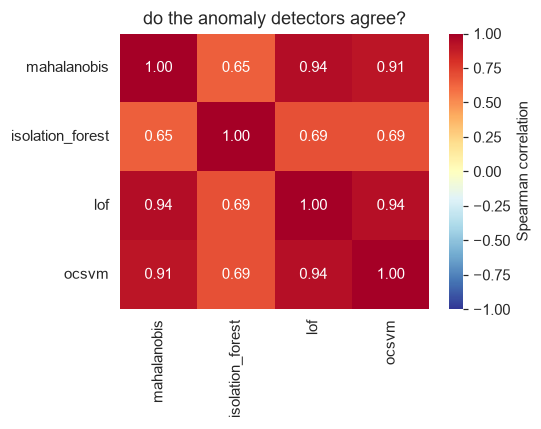

In [4]:
# How correlated are the four detectors? If they were perfectly correlated,
# we'd have one detector four times. If they were uncorrelated, we'd have
# four independent opinions. Reality is somewhere in between, and the
# disagreements are where the most interesting cases live.

detector_cols = ["mahalanobis", "isolation_forest", "lof", "ocsvm"]
corr = scores[detector_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdYlBu_r",
    vmin=-1, vmax=1, ax=ax, cbar_kws={"label": "Spearman correlation"},
)
ax.set_title("do the anomaly detectors agree?")
plt.tight_layout()
plt.show()

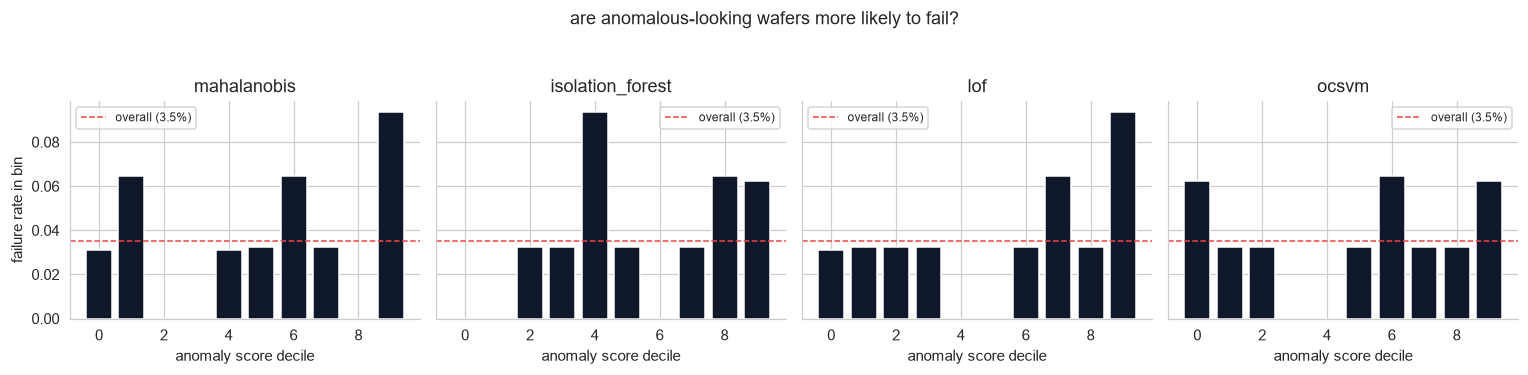

In [5]:
# For each detector: bin the val set into deciles by anomaly score and
# compute the failure rate in each bin. If anomaly-looking wafers were also
# failure-prone, the rightmost bin (most anomalous) would have a much
# higher failure rate than the leftmost.

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharey=True)

for ax, detector in zip(axes, detector_cols):
    # Bin by decile of anomaly score (10 equal-sized buckets).
    deciles = pd.qcut(scores[detector], q=10, labels=False, duplicates="drop")
    failure_rate_per_bin = scores.groupby(deciles)["is_failure"].mean()

    ax.bar(failure_rate_per_bin.index, failure_rate_per_bin.values, color="#0f172a")
    ax.axhline(y_val.mean(), color="#ef4444", linestyle="--", linewidth=1,
               label=f"overall ({y_val.mean()*100:.1f}%)")
    ax.set_title(detector)
    ax.set_xlabel("anomaly score decile")
    ax.legend(fontsize=8)

axes[0].set_ylabel("failure rate in bin")
plt.suptitle("are anomalous-looking wafers more likely to fail?", y=1.05)
plt.tight_layout()
plt.show()

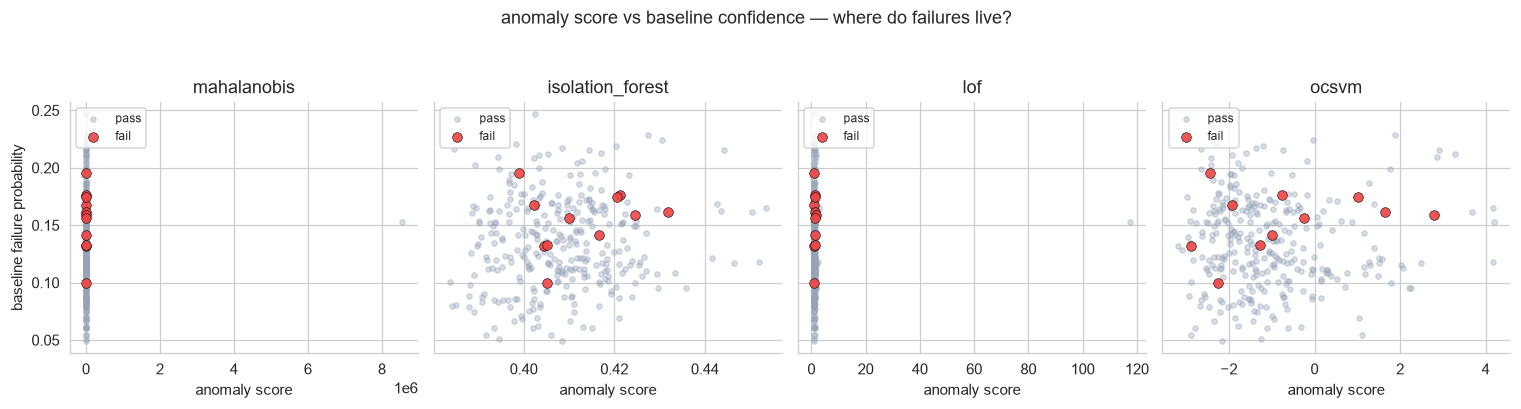

In [6]:
# The most useful comparison: anomaly score (x) vs baseline failure
# probability (y), colored by actual outcome. If they captured the same
# information, the cloud would lie along the diagonal. If they're
# complementary, we'll see real spread — and failures scattered through
# the high-x / high-y / both region.

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=True)

for ax, detector in zip(axes, detector_cols):
    passes = scores[scores["is_failure"] == 0]
    fails  = scores[scores["is_failure"] == 1]

    ax.scatter(passes[detector], passes["baseline_prob"],
               s=12, alpha=0.35, color="#94a3b8", label="pass")
    ax.scatter(fails[detector], fails["baseline_prob"],
               s=40, alpha=0.9, color="#ef4444", label="fail",
               edgecolor="black", linewidth=0.4)
    ax.set_title(detector)
    ax.set_xlabel("anomaly score")
    ax.legend(fontsize=8, loc="upper left")

axes[0].set_ylabel("baseline failure probability")
plt.suptitle("anomaly score vs baseline confidence — where do failures live?", y=1.05)
plt.tight_layout()
plt.show()

In [7]:
# Build a simple ensemble: rank-average the four detectors. Ranks remove
# the scale differences and give a robust combined score. Then save
# everything we need for later blocks.

from scipy.stats import rankdata
import os, json

# Rank each detector's val scores (1 = most normal, len = most anomalous),
# then average. The result is a single anomaly score per wafer.
ranks = np.column_stack([rankdata(scores[d]) for d in detector_cols])
ensemble_score = ranks.mean(axis=1)
scores["ensemble"] = ensemble_score

# Quick check: does the ensemble do better than any individual at finding
# failures in the top-K most-anomalous wafers?
from sklearn.metrics import average_precision_score

print("PR-AUC of each anomaly score vs actual failures:")
for col in detector_cols + ["ensemble"]:
    ap = average_precision_score(scores["is_failure"], scores[col])
    print(f"  {col:18s}  {ap:.3f}")
print(f"  baseline_prob       {average_precision_score(scores['is_failure'], scores['baseline_prob']):.3f}")

# Save the trained detectors so we can reuse them in the production pipeline.
os.makedirs("../results/models", exist_ok=True)
joblib.dump(mahalanobis_model, "../results/models/anomaly_mahalanobis.pkl")
joblib.dump(isoforest,         "../results/models/anomaly_isoforest.pkl")
joblib.dump(lof,               "../results/models/anomaly_lof.pkl")
joblib.dump(ocsvm,             "../results/models/anomaly_ocsvm.pkl")

# Save the val scores too — Block 9 will use these to calibrate thresholds.
scores.to_csv("../data/processed/val_anomaly_scores.csv", index=False)

print("\nsaved detectors and val scores.")

PR-AUC of each anomaly score vs actual failures:
  mahalanobis         0.057
  isolation_forest    0.060
  lof                 0.068
  ocsvm               0.060
  ensemble            0.070
  baseline_prob       0.057

saved detectors and val scores.
